# MOKE than a feeling


### Task
calculate the longitudinal Kerr rotation of Fe from the s- and p-polarized data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
Pi = np.pi

In [2]:
data=[[],[]]
label=[[],[]]
k=0
for letter in ['p','s']:
    j=0
    for sign in ['-','+']:
        for i in range(8):
            file = "data/contrast_"+letter+"/"+sign+str(i)
            x = np.loadtxt(file, dtype=np.str, delimiter='\t', unpack=True)
            x = np.char.replace(x, ',', '.')
            x = np.char.replace(x, '\'', '')
            x = np.char.replace(x, 'b', '').astype(np.float64)
            data[k].append(x)
            label[k].append(letter+"/"+sign+str(i))
        j=1
    k=1

In [3]:
label

[['p/-0',
  'p/-1',
  'p/-2',
  'p/-3',
  'p/-4',
  'p/-5',
  'p/-6',
  'p/-7',
  'p/+0',
  'p/+1',
  'p/+2',
  'p/+3',
  'p/+4',
  'p/+5',
  'p/+6',
  'p/+7'],
 ['s/-0',
  's/-1',
  's/-2',
  's/-3',
  's/-4',
  's/-5',
  's/-6',
  's/-7',
  's/+0',
  's/+1',
  's/+2',
  's/+3',
  's/+4',
  's/+5',
  's/+6',
  's/+7']]

In [4]:
volt = [0,-1,-2,-3,-4,-5,-6,-7,0,1,2,3,4,5,6,7]

In [5]:
offset= [[0.005, 0.005,0.005,1.406,2.634,4.146,6.14,8.568,
         0.005,0.005,0.005,2.322,3.762,5.686,8.042,10.686],
         [0.007, 0.007, 1.979, 3.844, 6.344, 9.347, 12.94, 17.125,
        0.007, 0.007, 0.007, 1.903, 3.757, 6.202, 9.418, 13.198]]

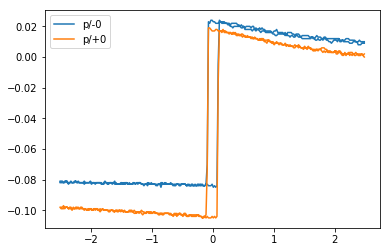

In [6]:
plt.plot(data[0][0][0],data[0][0][1])
plt.plot(data[0][8][0],data[0][8][1])
plt.legend([label[0][0],label[0][8]])

In [7]:
for j in range(2):
    for i in range(16):
        data[j][i][1]+=offset[j][i]

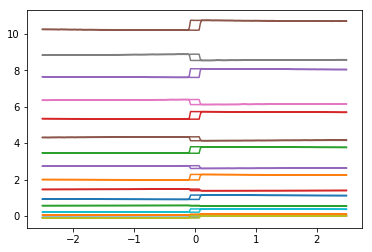

In [8]:
for i in range(16):
    plt.plot(data[0][i][0],data[0][i][1],'-')

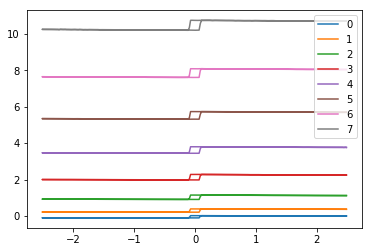

In [10]:
for i in range(8,16):
    plt.plot(data[0][i][0],data[0][i][1])
plt.legend([i for i in range(8)])

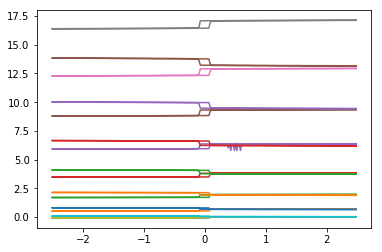

In [11]:
for i in range(16):
    plt.plot(data[1][i][0],data[1][i][1],'-')

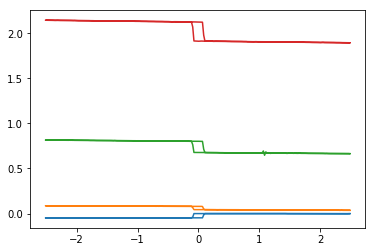

In [12]:
for i in range(8,12):
    plt.plot(data[1][i][0],data[1][i][1])

In [13]:
phase = [[1,1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1,1,1],[1,1,1,1,1,1,1,1,1,-1,-1,-1,-1,-1,-1,-1]]

In [14]:
def hystfit (x, phase, rescx, rescy, offset):
    return offset + np.sign(phase)*rescy*np.arctan(rescx*x)

In [15]:
def hystfit2 (x, phase, rescx, rescy, offset, slope):
    return offset + slope*x + np.sign(phase)*rescy*np.arctan(rescx*x)

In [17]:
pars, errors = curve_fit(hystfit, data[1][11][0],data[1][11][1], [-1, 1, 0.5,2], maxfev=100000)
pars2, errors2 = curve_fit(hystfit2, data[1][11][0],data[1][11][1], [-1, 1, 0.5,2, 0], maxfev=100000)

In [18]:
pars, pars2

(array([-1.        , 12.50575579,  0.07858369,  2.02062824]),
 array([-1.00000000e+00,  1.28892293e+01,  7.75913050e-02,  2.02062339e+00,
        -9.26203662e-04]))

In [19]:
test = np.linspace(-2.5,2.5,150)
tyst = hystfit(test, -1, 12.5, 0.0785, 2.021)
tyst2 = hystfit2(test, -1, 12.889, 0.0759, 2.0206, -0.0009262)

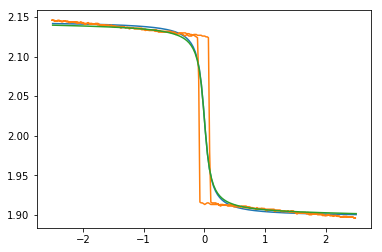

In [20]:
plt.plot(test,tyst)
plt.plot(data[1][11][0],data[1][11][1])
plt.plot(test, tyst2)

In [27]:
Iplus = np.max(tyst)
Iminus = np.min(tyst)
Ipplus= pars[3]+0.5*Pi*pars[2]
Imminus = pars[3]-0.5*Pi*pars[2]
Ippplus = np.max(tyst2)
Immminus = np.min(tyst2)

In [28]:
Iplus, Ipplus, Ippplus

(2.141796368556313, 2.1440672133260827, 2.139784200042378)

In [29]:
2*(Iplus-Iminus)/(Iplus+Iminus)

0.11954118610223953

In [30]:
2*(Ipplus-Imminus)/(Ipplus+Imminus)

0.12217880250245132

In [31]:
2*(Ippplus-Immminus)/(Ippplus+Immminus)

0.11796911812568342

In [21]:
contrast=[[],[]]
for j in range(2):
    for i in range(16):
        pars, errors = curve_fit(hystfit, data[j][i][0], data[j][i][1], [phase[j][i], 1, 0.5, offset[j][i]])
        contrast[j].append(Pi*pars[2]/pars[3])

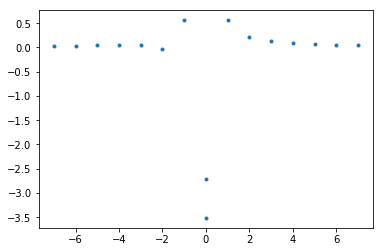

In [33]:
plt.plot(volt, contrast[0],'.')

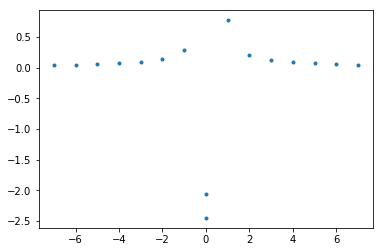

In [34]:
plt.plot(volt, contrast[1],'.')

In [22]:
contrast2=[[],[]]
for j in range(2):
    for i in range(16):
        pars, errors = curve_fit(hystfit2, data[j][i][0], data[j][i][1], [phase[j][i], 1, 0.5, offset[j][i],0])
        contrast2[j].append(Pi*pars[2]/pars[3])

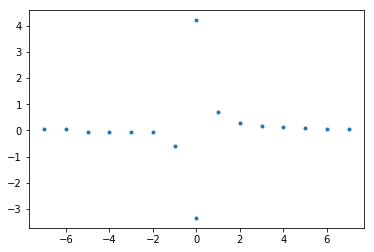

In [23]:
plt.plot(volt, contrast2[0],'.')

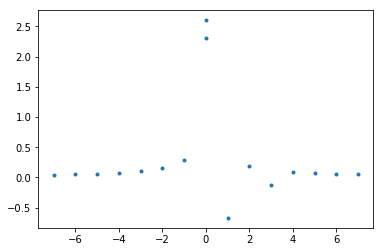

In [24]:
plt.plot(volt, contrast2[1],'.')

In [25]:
def Kerrangle (x, kerr):
    return 4*kerr/x

In [26]:
def notsosmallKerr (x, kerr):
    return 4*x*kerr/(x*x+kerr*kerr)

In [27]:
angle, error = curve_fit(Kerrangle, volt[1:8]+volt[9:16], contrast2[0][1:8]+contrast2[0][9:16], maxfev=10000)

In [28]:
angle, error

(array([0.13307056]), array([[0.00021438]]))

In [29]:
notsosmallangle, notsosmallerror = curve_fit(notsosmallKerr, volt, contrast2[0], maxfev=10000)

In [30]:
notsosmallangle, notsosmallerror

(array([0.13384927]), array([[0.04318903]]))

In [31]:
xfunc = np.linspace(-7, 0.05, 150)+np.linspace(0.15, 7, 150)

In [32]:
notsosmallxfunc = np.linspace(-7,7,150)
notsosmallyfunc = notsosmallKerr(notsosmallxfunc, notsosmallangle)

In [33]:
yfunc = Kerrangle(xfunc, angle)

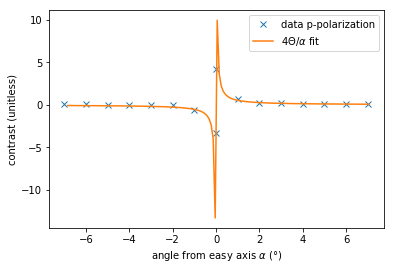

In [66]:
plt.plot(volt, contrast2[0], 'x')
plt.plot(xfunc, yfunc)
plt.xlabel(r"angle from easy axis $\alpha$ ($\degree$)")
plt.ylabel("contrast (unitless)")
plt.legend(["data p-polarization", r"$4\Theta/\alpha$ fit"])
plt.savefig('plots/p-contrast.png')

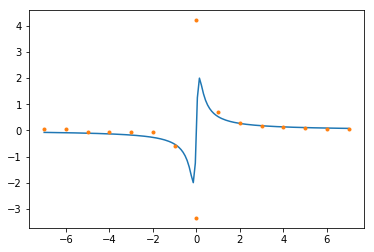

In [40]:
plt.plot(notsosmallxfunc, notsosmallyfunc)
plt.plot(volt, contrast2[0], '.')

In [41]:
angle1, error1 = curve_fit(Kerrangle, volt[1:8]+volt[9:16], contrast2[1][1:8]+contrast2[1][9:16], maxfev=10000)

In [42]:
angle1, error1

(array([-0.08368231]), array([[0.00050227]]))

In [43]:
notsosmallangle1, notsosmallerror1 = curve_fit(notsosmallKerr, volt, contrast2[1], maxfev=10000)

In [44]:
notsosmallangle1, notsosmallerror1

(array([-0.08367016]), array([[0.01760919]]))

In [45]:
notsosmallxfunc1 = np.linspace(-7,7,150)
notsosmallyfunc1 = notsosmallKerr(notsosmallxfunc1, notsosmallangle1)

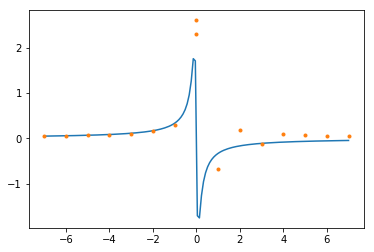

In [46]:
plt.plot(notsosmallxfunc1, notsosmallyfunc1)
plt.plot(volt, contrast2[1], '.')

In [78]:
xfunc1 = np.linspace(-7, 0.05, 150)+np.linspace(0.15, 7, 150)

In [79]:
yfunc1 = Kerrangle(xfunc1, angle1)

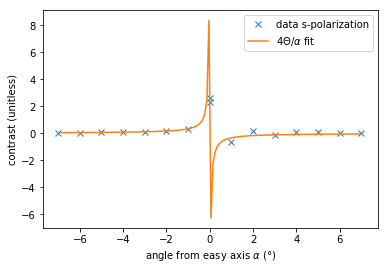

In [81]:
plt.plot(volt, contrast2[1], 'x')
plt.plot(xfunc1, yfunc1)
plt.xlabel(r"angle from easy axis $\alpha$ ($\degree$)")
plt.ylabel("contrast (unitless)")
plt.legend(["data s-polarization", r"$4\Theta/\alpha$ fit"])
plt.savefig('plots/s-contrast.png')

In [118]:
angle, error = curve_fit(Kerrangle, volt[1:8], contrast[0][1:8], [0], maxfev=1000000)

In [119]:
angle2, error2 = curve_fit(Kerrangle, volt[9:], contrast2[0][9:], [0], maxfev=1000000)

In [120]:
angle, angle2

(array([-0.09881198]), array([0.15535814]))

In [121]:
xfunc = np.linspace(volt[7],-0.1,150)
xfunc2 = np.linspace(0.1, volt[15], 150)

In [122]:
yfunc = -Kerrangle(xfunc, angle)
yfunc2 = Kerrangle(xfunc2, angle2)

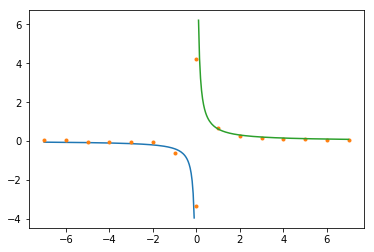

In [123]:
plt.plot(xfunc, yfunc)
plt.plot(volt, contrast2[0],'.')
plt.plot(xfunc2,yfunc2)

In [95]:
angle3, error3 = curve_fit(Kerrangle, volt[1:8], contrast[1][1:8], [0], maxfev=1000000)

In [124]:
angle4, error4 = curve_fit(Kerrangle, volt[9:], contrast2[1][9:], [0], maxfev=1000000)

In [125]:
angle3, angle4

(array([-0.07256541]), array([-0.0927883]))

In [129]:
xfunc3 = np.linspace(volt[7],-0.05,150)
xfunc4 = np.linspace(0.05, volt[15], 150)

In [135]:
yfunc3 = Kerrangle(xfunc3, angle3)
yfunc4 = Kerrangle(xfunc4, angle4)

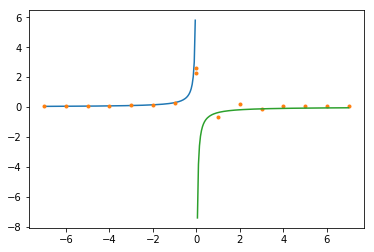

In [136]:
plt.plot(xfunc3, yfunc3)
plt.plot(volt, contrast2[1],'.')
plt.plot(xfunc4,yfunc4)